In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Import daily runner data
run_ww_2019_d = pd.read_csv('run_ww_2019_d.csv')
run_ww_2019_d.head()

,Unnamed: 0,datetime,athlete,distance,duration,gender,age_group,country,major
0,0,2019-01-01,0,0.00,0.00,F,18 - 34,United States,CHICAGO 2019
1,1,2019-01-01,1,5.27,30.20,M,35 - 54,Germany,BERLIN 2016
2,2,2019-01-01,2,0.00,0.00,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"
3,3,2019-01-01,3,10.50,43.95,M,18 - 34,United Kingdom,LONDON 2017
4,4,2019-01-01,4,9.66,48.65,M,35 - 54,United States,BOSTON 2017


# Distance

In [4]:
# Sample of 1000 runners
distance = run_ww_2019_d["distance"]
distance = pd.Series(distance).dropna().astype(float)
distance = distance.iloc[:1000]
distance.head()

0     0.00
1     5.27
2     0.00
3    10.50
4     9.66
Name: distance, dtype: float64

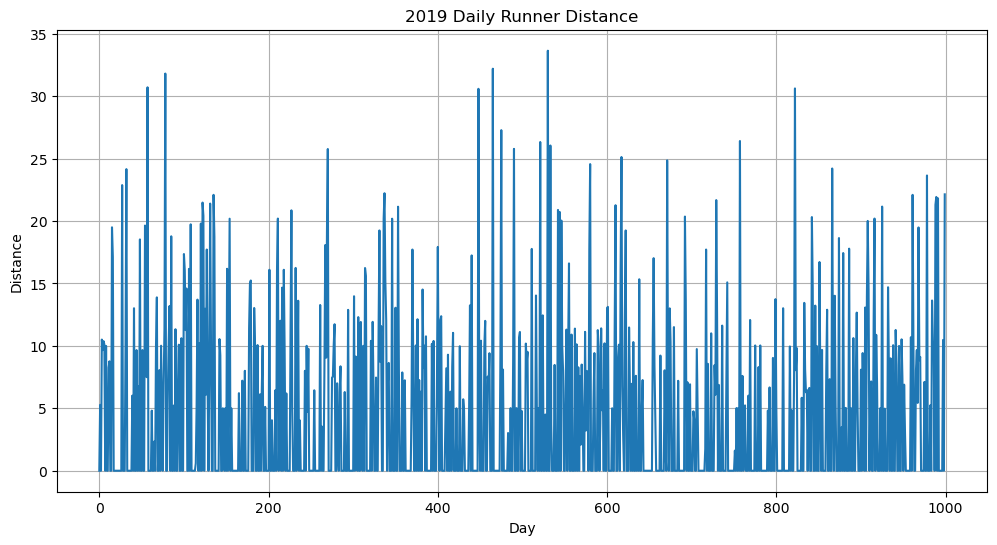

In [5]:
# Time series plot
plt.figure(figsize=(12,6))
plt.plot(distance)
plt.title("2019 Daily Runner Distance")
plt.xlabel("Day")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

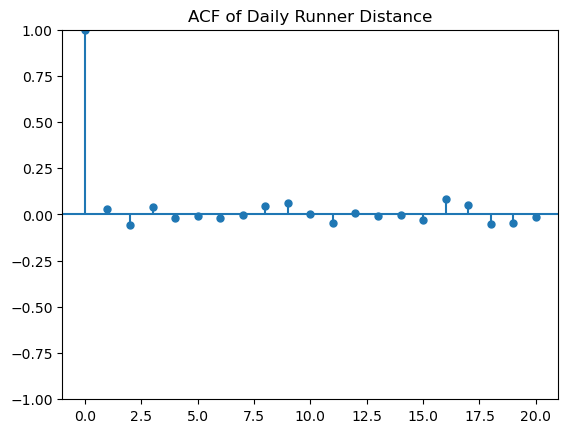

In [6]:
# Plot ACF
plt.figure(figsize=(10,5))
plot_acf(distance, lags=20, alpha=None)
plt.title("ACF of Daily Runner Distance")
plt.show()

After lag 1, all correlations are very small and fluctuate around zero. There is no gradual decay pattern.

<Figure size 1000x500 with 0 Axes>

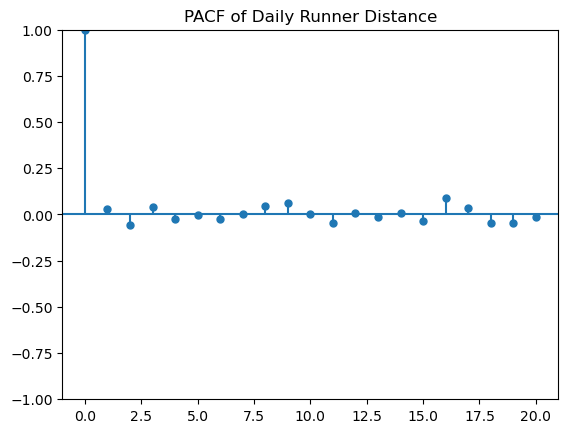

In [8]:
# Plot PACF 
plt.figure(figsize=(10,5))
plot_pacf(distance, lags=20, alpha=None)
plt.title("PACF of Daily Runner Distance")
plt.show()

There are no strong spikes after lag 1. Values stay close to zero.

In [10]:
# Split into training and test sets
# Take instead the first 80% for the training, then we'll see if the first 80% of distances can be used to predict the next 20%
dist_train_size = int(.8 * len(distance))
dist_train_data = distance[:dist_train_size]
dist_test_data = distance[dist_train_size:]

# Put the y feature in arrays
dist_y_train = np.array(dist_train_data)
dist_y_test = np.array(dist_test_data)

In [11]:
# Try ARIMA(1,0,1)
from statsmodels.tsa.arima.model import ARIMA

dist_ar_model = ARIMA(dist_y_train, order=(1, 0, 1))
dist_ar_fit = dist_ar_model.fit()

# Print summary ARIMA model
print(dist_ar_fit.summary())
abs(dist_ar_fit.maroots)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  800
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2645.884
Date:                Thu, 12 Mar 2026   AIC                           5299.769
Time:                        15:51:39   BIC                           5318.507
Sample:                             0   HQIC                          5306.967
                                - 800                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4454      0.380     11.696      0.000       3.700       5.190
ar.L1         -0.6276      0.291     -2.157      0.031      -1.198      -0.057
ma.L1          0.6847      0.272      2.517      0.0

array([1.46038995])

In [20]:
# Make predictions from model
dist_ar_pred = dist_ar_fit.predict(start=len(dist_train_data), end=len(dist_train_data) + len(dist_test_data) - 1)
dist_ar_pred_data = pd.DataFrame({'Day': dist_test_data.index, 'Predicted Distances': dist_ar_pred.flatten()})
dist_ar_pred_data.set_index('Day', inplace = True)
dist_ar_pred_data.head()

,Predicted Distances
Day,
800,4.878918
801,4.173359
802,4.616184
803,4.338257
804,4.512690


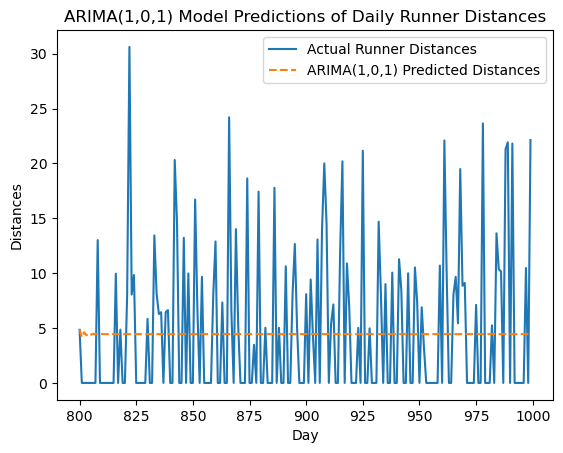

In [24]:
# Make the plot
plt.plot(dist_test_data, label = 'Actual Runner Distances')
plt.plot(dist_ar_pred_data['Predicted Distances'], label = 'ARIMA(1,0,1) Predicted Distances', linestyle = '--')
plt.xlabel('Day')
plt.ylabel('Distances')
plt.legend()
plt.title('ARIMA(1,0,1) Model Predictions of Daily Runner Distances')
plt.show()

# Duration

In [26]:
duration = run_ww_2019_d["duration"]
duration = pd.Series(duration).dropna().astype(float)
duration = duration.iloc[:1000]
duration.head()

0     0.00
1    30.20
2     0.00
3    43.95
4    48.65
Name: duration, dtype: float64

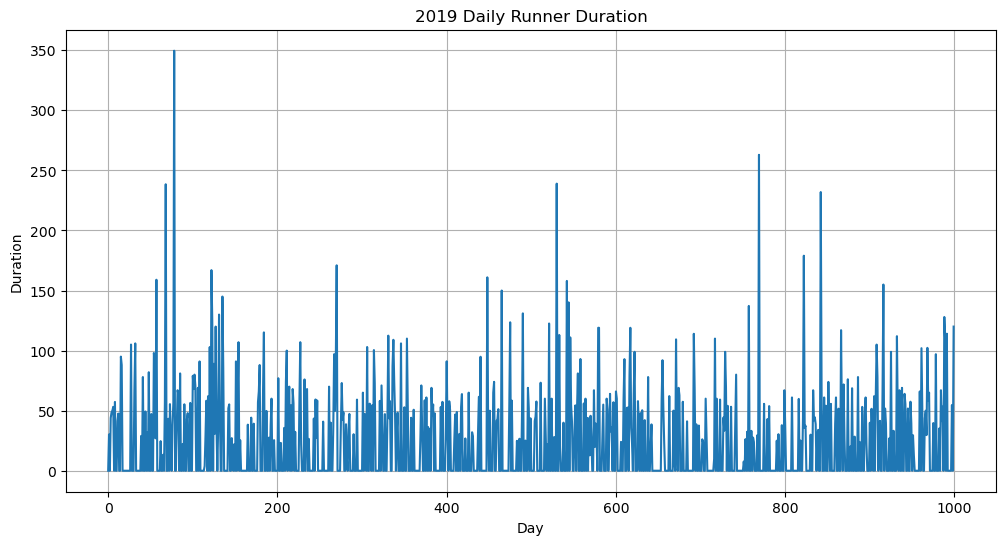

In [28]:
# Time series plot
plt.figure(figsize=(12,6))
plt.plot(duration)

plt.title("2019 Daily Runner Duration")
plt.xlabel("Day")
plt.ylabel("Duration")
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

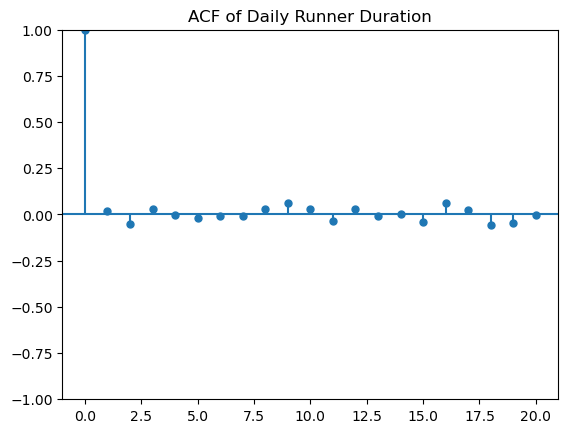

In [30]:
# Plot ACF
plt.figure(figsize=(10,5))
plot_acf(duration, lags=20, alpha=None)
plt.title("ACF of Daily Runner Duration")
plt.show()

After lag 1, all correlations are very small and fluctuate around zero. There is no gradual decay pattern.

<Figure size 1000x500 with 0 Axes>

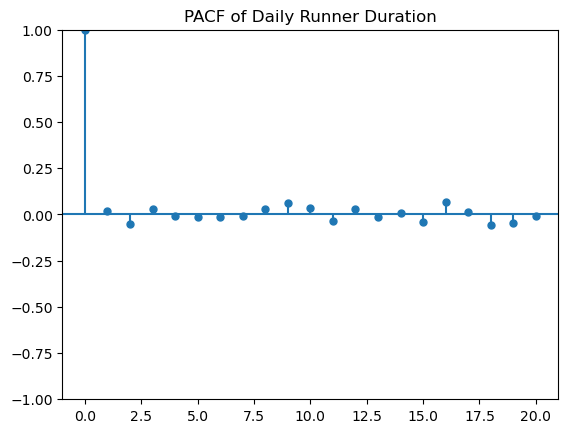

In [32]:
# Plot PACF 
plt.figure(figsize=(10,5))
plot_pacf(duration, lags=20, alpha=None)
plt.title("PACF of Daily Runner Duration")
plt.show()

There are no strong spikes after lag 1. Values stay close to zero.

In [34]:
# Split into training and test sets
# Take instead the first 80% for the training, then we'll see if the first 80% of distances can be used to predict the next 20%
dur_train_size = int(.8 * len(duration))
dur_train_data = duration[:dur_train_size]
dur_test_data = duration[dur_train_size:]

# Put the y feature in arrays
dur_y_train = np.array(dur_train_data)
dur_y_test = np.array(dur_test_data)

In [36]:
# Try ARIMA(1,0,1)
from statsmodels.tsa.arima.model import ARIMA

dur_ar_model = ARIMA(dur_y_train, order=(1, 0, 1))
dur_ar_fit = dur_ar_model.fit()

# Print summary ARIMA model
print(dur_ar_fit.summary())
abs(dur_ar_fit.maroots)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  800
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -4058.718
Date:                Thu, 12 Mar 2026   AIC                           8125.436
Time:                        15:53:12   BIC                           8144.175
Sample:                             0   HQIC                          8132.635
                                - 800                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.4508      1.953     12.520      0.000      20.623      28.278
ar.L1         -0.5970      0.561     -1.064      0.287      -1.697       0.503
ma.L1          0.6329      0.540      1.171      0.2

array([1.58003027])

In [38]:
# Make predictions from model
dur_ar_pred = dur_ar_fit.predict(start=len(dur_train_data), end=len(dur_train_data) + len(dur_test_data) - 1)
dur_ar_pred_data = pd.DataFrame({'Day': dur_test_data.index, 'Predicted Durations': dur_ar_pred.flatten()})
dur_ar_pred_data.set_index('Day', inplace = True)
dur_ar_pred_data.head()

,Predicted Durations
Day,
800,25.916047
801,23.576015
802,24.972968
803,24.139015
804,24.636869


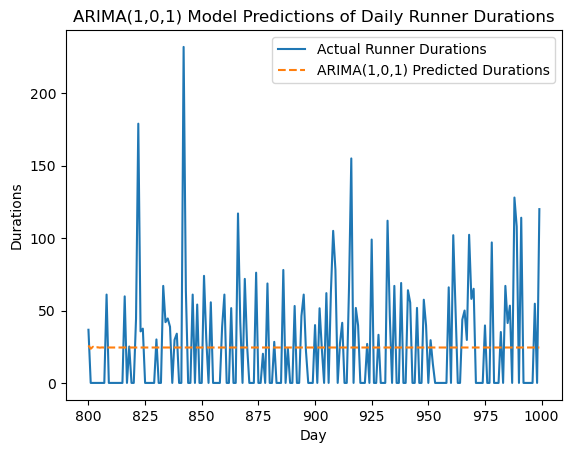

In [42]:
# Make the plot
plt.plot(dur_test_data, label = 'Actual Runner Durations')
plt.plot(dur_ar_pred_data['Predicted Durations'], label = 'ARIMA(1,0,1) Predicted Durations', linestyle = '--')
plt.xlabel('Day')
plt.ylabel('Durations')
plt.legend()
plt.title('ARIMA(1,0,1) Model Predictions of Daily Runner Durations')
plt.show()